In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mistermprah/power-regional-monthly-1984-2025-ghana/POWER_Regional_Monthly_1984_2025.csv


## IMPORTS

In [3]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

2026-08-27 19:36:41.997274: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787859402.194579      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787859402.246402      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1787859402.706735      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787859402.706781      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1787859402.706784      58 computation_placer.cc:177] computation placer alr

## CONFIGURATION 

In [4]:
FILE_PATH = "/kaggle/input/datasets/mistermprah/power-regional-monthly-1984-2025-ghana/POWER_Regional_Monthly_1984_2025.csv"

PARAMETER = "T2M"
AGG_METHOD = "mean"

LAG_MONTHS = 24
ROLL_WINDOWS = [3, 6, 12]
TEST_SIZE_RATIO = 0.2

NB_BINS = 3
AUGMENT_NOISE_STD = 0.01
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

## LOADING AND RESHAPING DATA

In [5]:
df = pd.read_csv(FILE_PATH, skiprows=9)

df = df[df["PARAMETER"] == PARAMETER].copy()

monthly_cols = ["JAN","FEB","MAR","APR","MAY","JUN",
                "JUL","AUG","SEP","OCT","NOV","DEC"]

needed_cols = ["PARAMETER", "YEAR", "LAT", "LON"] + monthly_cols
df = df[needed_cols].copy()

if AGG_METHOD == "mean":
    df_agg = df.groupby("YEAR")[monthly_cols].mean().reset_index()
else:
    raise ValueError("Only mean aggregation is implemented.")

ts = df_agg.melt(
    id_vars="YEAR",
    value_vars=monthly_cols,
    var_name="MONTH",
    value_name="VALUE"
)

month_map = {m: i+1 for i, m in enumerate(monthly_cols)}
ts["MONTH_NUM"] = ts["MONTH"].map(month_map)

ts["DATE"] = pd.to_datetime(
    ts["YEAR"].astype(str) + "-" + ts["MONTH_NUM"].astype(str)
)

ts = ts.sort_values("DATE").reset_index(drop=True)
ts = ts[["DATE", "VALUE"]].copy()

ts.head()

,DATE,VALUE
0,1984-01-01,27.267473
1,1984-02-01,28.501648
2,1984-03-01,28.207143
3,1984-04-01,27.466703
4,1984-05-01,26.466813


## DATA CLEANING

In [6]:
ts["VALUE"] = pd.to_numeric(ts["VALUE"], errors="coerce")
ts["DATE"] = pd.to_datetime(ts["DATE"])

ts = ts.set_index("DATE")

ts["VALUE"] = ts["VALUE"].interpolate(method="time", limit_direction="both")
ts["VALUE"] = ts["VALUE"].fillna(ts["VALUE"].median())

ts = ts.reset_index()

low_q = ts["VALUE"].quantile(0.01)
high_q = ts["VALUE"].quantile(0.99)

ts["VALUE_CLIPPED"] = ts["VALUE"].clip(lower=low_q, upper=high_q)

ts["VALUE_SMOOTH"] = ts["VALUE_CLIPPED"].rolling(3).mean()
ts["VALUE_SMOOTH"] = ts["VALUE_SMOOTH"].fillna(ts["VALUE_CLIPPED"])

ts["Y"] = ts["VALUE_SMOOTH"]

ts.head()

,DATE,VALUE,VALUE_CLIPPED,VALUE_SMOOTH,Y
0,1984-01-01,27.267473,27.267473,27.267473,27.267473
1,1984-02-01,28.501648,28.501648,28.501648,28.501648
2,1984-03-01,28.207143,28.207143,27.992088,27.992088
3,1984-04-01,27.466703,27.466703,28.058498,28.058498
4,1984-05-01,26.466813,26.466813,27.380220,27.380220


## EXPLORATORY DATA ANALYSIS

Date range: 1984-01-01 00:00:00 to 2025-12-01 00:00:00
                Y
count  504.000000
mean    26.663461
std      1.264655
min     24.174223
25%     25.621978
50%     26.357875
75%     27.683663
max     29.855869


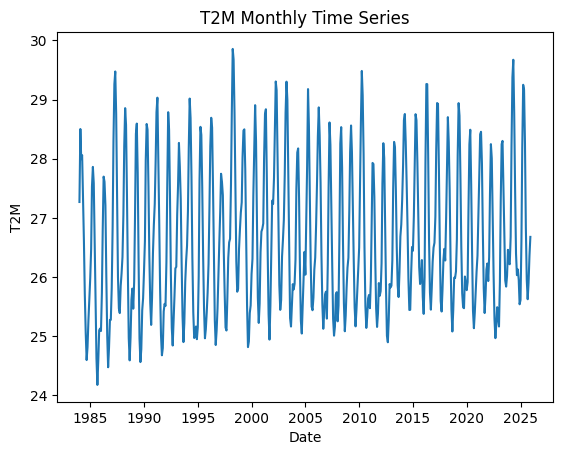

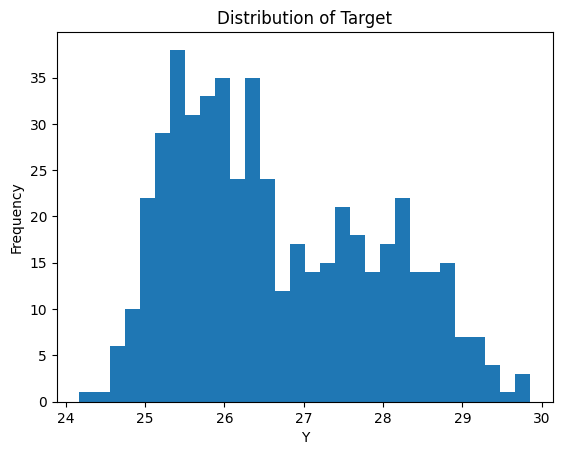

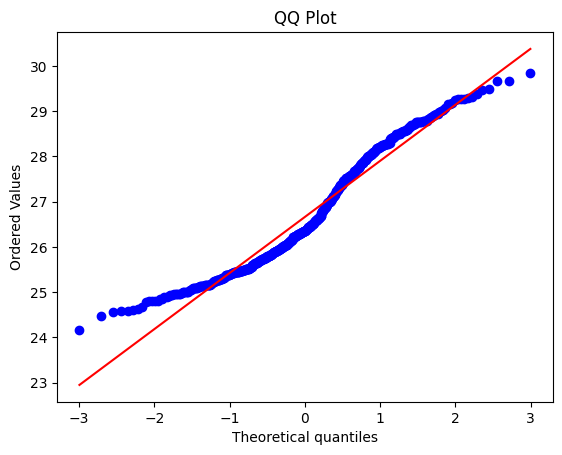

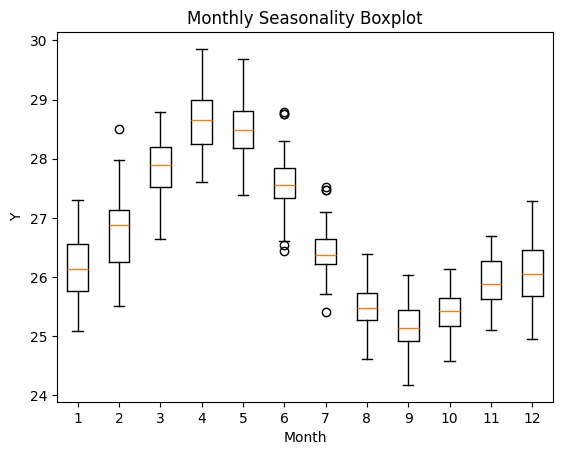

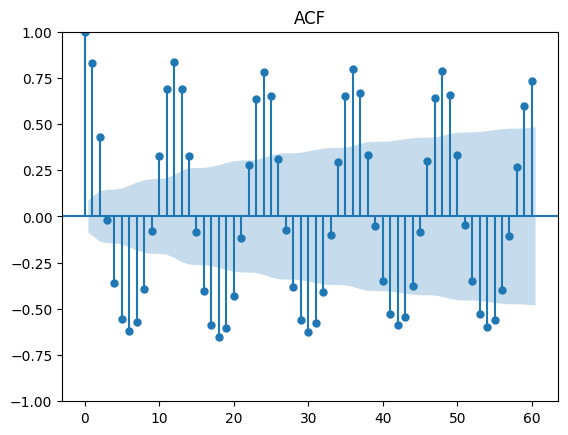

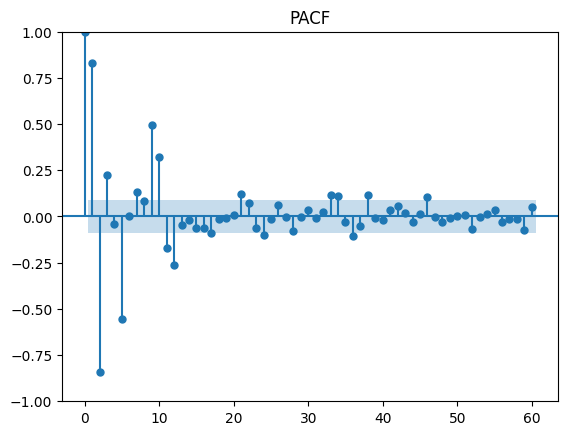

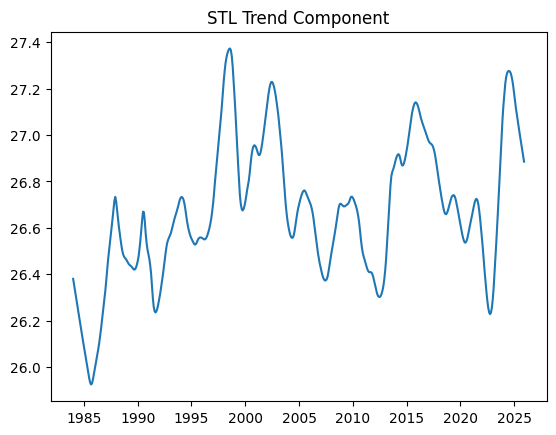

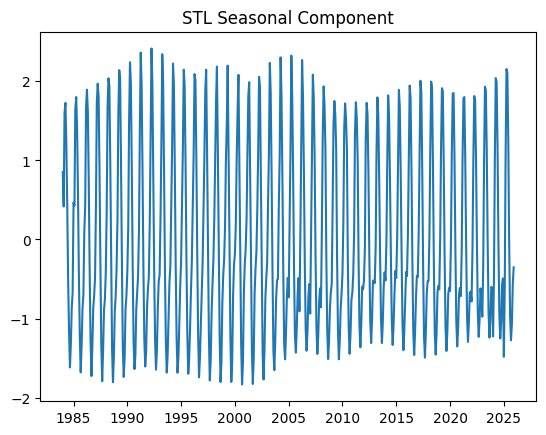

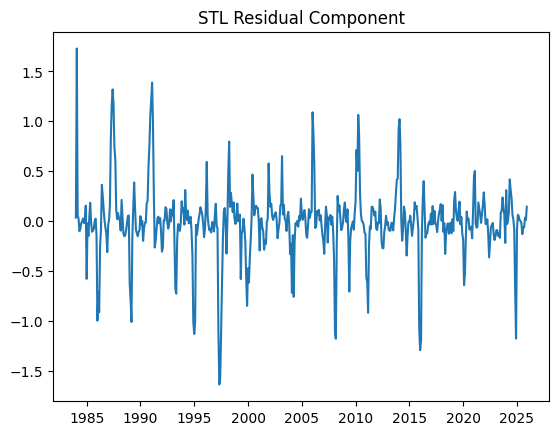

In [7]:
print("Date range:", ts["DATE"].min(), "to", ts["DATE"].max())
print(ts[["Y"]].describe())

plt.figure()
plt.plot(ts["DATE"], ts["Y"])
plt.title(f"{PARAMETER} Monthly Time Series")
plt.xlabel("Date")
plt.ylabel(PARAMETER)
plt.show()

plt.figure()
plt.hist(ts["Y"], bins=30)
plt.title("Distribution of Target")
plt.xlabel("Y")
plt.ylabel("Frequency")
plt.show()

plt.figure()
stats.probplot(ts["Y"], dist="norm", plot=plt)
plt.title("QQ Plot")
plt.show()

ts["MONTH"] = ts["DATE"].dt.month
month_data = [ts.loc[ts["MONTH"] == m, "Y"].values for m in range(1, 13)]

plt.figure()
plt.boxplot(month_data, labels=list(range(1, 13)))
plt.title("Monthly Seasonality Boxplot")
plt.xlabel("Month")
plt.ylabel("Y")
plt.show()

plt.figure()
plot_acf(ts["Y"], lags=60, ax=plt.gca())
plt.title("ACF")
plt.show()

plt.figure()
plot_pacf(ts["Y"], lags=60, ax=plt.gca(), method="ywm")
plt.title("PACF")
plt.show()

stl = STL(ts["Y"], period=12, robust=True).fit()

plt.figure()
plt.plot(ts["DATE"], stl.trend)
plt.title("STL Trend Component")
plt.show()

plt.figure()
plt.plot(ts["DATE"], stl.seasonal)
plt.title("STL Seasonal Component")
plt.show()

plt.figure()
plt.plot(ts["DATE"], stl.resid)
plt.title("STL Residual Component")
plt.show()

## FEATURE ENGINEERING

In [8]:
feat = ts[["DATE", "Y"]].copy()

feat["t"] = np.arange(len(feat))

feat["month"] = feat["DATE"].dt.month
feat["month_sin"] = np.sin(2 * np.pi * feat["month"] / 12)
feat["month_cos"] = np.cos(2 * np.pi * feat["month"] / 12)

for l in range(1, LAG_MONTHS + 1):
    feat[f"lag_{l}"] = feat["Y"].shift(l)

for w in ROLL_WINDOWS:
    feat[f"roll_mean_{w}"] = feat["Y"].shift(1).rolling(w).mean()
    feat[f"roll_std_{w}"] = feat["Y"].shift(1).rolling(w).std()
    feat[f"roll_min_{w}"] = feat["Y"].shift(1).rolling(w).min()
    feat[f"roll_max_{w}"] = feat["Y"].shift(1).rolling(w).max()

feat = feat.dropna().reset_index(drop=True)

feat.head()

,DATE,Y,t,month,month_sin,month_cos,lag_1,lag_2,lag_3,lag_4,...,roll_min_3,roll_max_3,roll_mean_6,roll_std_6,roll_min_6,roll_max_6,roll_mean_12,roll_std_12,roll_min_12,roll_max_12
0,1986-01-01,25.085751,24,1,0.500000,8.660254e-01,25.127143,25.097729,24.582277,24.174223,...,24.582277,25.127143,24.836098,0.455430,24.174223,25.414804,25.915793,1.276440,24.174223,27.860806
1,1986-02-01,25.732711,25,2,0.866025,5.000000e-01,25.085751,25.127143,25.097729,24.582277,...,25.085751,25.127143,24.781256,0.386384,24.174223,25.127143,25.841505,1.298295,24.174223,27.860806
2,1986-03-01,26.787839,26,3,1.000000,6.123234e-17,25.732711,25.085751,25.127143,25.097729,...,25.085751,25.732711,24.966639,0.532852,24.174223,25.732711,25.779884,1.283100,24.174223,27.860806
3,1986-04-01,27.696410,27,4,0.866025,-5.000000e-01,26.787839,25.732711,25.085751,25.127143,...,25.085751,26.787839,25.402241,0.770715,24.582277,26.787839,25.717991,1.206610,24.174223,27.860806
4,1986-05-01,27.608718,28,5,0.500000,-8.660254e-01,27.696410,26.787839,25.732711,25.085751,...,25.732711,27.696410,25.921264,1.090373,25.085751,27.696410,25.704292,1.180725,24.174223,27.696410


## TRAIN/TEST SPLIT AND SCALNG

In [9]:
N = len(feat)
test_n = int(np.ceil(TEST_SIZE_RATIO * N))

train_df = feat.iloc[:-test_n].copy()
test_df = feat.iloc[-test_n:].copy()

X_train = train_df.drop(columns=["DATE", "Y"]).values
y_train = train_df["Y"].values

X_test = test_df.drop(columns=["DATE", "Y"]).values
y_test = test_df["Y"].values

dates_train = train_df["DATE"].values
dates_test = test_df["DATE"].values

x_scaler = RobustScaler()
y_scaler = RobustScaler()

X_train_s = x_scaler.fit_transform(X_train)
X_test_s = x_scaler.transform(X_test)

y_train_s = y_scaler.fit_transform(y_train.reshape(-1, 1)).ravel()
y_test_s = y_scaler.transform(y_test.reshape(-1, 1)).ravel()

y_test_inv = y_scaler.inverse_transform(y_test_s.reshape(-1, 1)).ravel()

## DATA AUGMENTATION

In [10]:
def augment_jitter(X, y, noise_std=0.01, copies=2):
    X_list = [X]
    y_list = [y]

    for _ in range(copies):
        noise = np.random.normal(0, noise_std, size=X.shape)
        X_list.append(X + noise)
        y_list.append(y.copy())

    return np.vstack(X_list), np.hstack(y_list)

X_train_aug, y_train_aug = augment_jitter(
    X_train_s,
    y_train_s,
    noise_std=AUGMENT_NOISE_STD,
    copies=2
)

## HELPER DUNCTIONS

In [11]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2


def plot_actual_vs_pred(dates, y_true, y_pred, title):
    plt.figure(figsize=(10, 4))
    plt.plot(dates, y_true, label="Actual")
    plt.plot(dates, y_pred, label="Predicted")
    plt.title(title)
    plt.xlabel("Date")
    plt.ylabel(PARAMETER)
    plt.legend()
    plt.show()


def plot_residuals(y_true, y_pred, title):
    resid = y_true - y_pred

    plt.figure()
    plt.hist(resid, bins=30)
    plt.title(f"{title} Residual Distribution")
    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.show()

    plt.figure()
    plt.scatter(y_true, y_pred, s=12)
    plt.title(f"{title} Actual vs Predicted Scatter")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

## SUPPORT VECTOR REGRESSION - SVR

Best SVR params: {'C': 10, 'epsilon': 0.01, 'gamma': 0.01}
SVR Metrics: {'MAE': 0.18703770927849608, 'RMSE': np.float64(0.24422198296532038), 'MAPE%': np.float64(0.6949874653613759), 'R2': 0.9576915687119273}


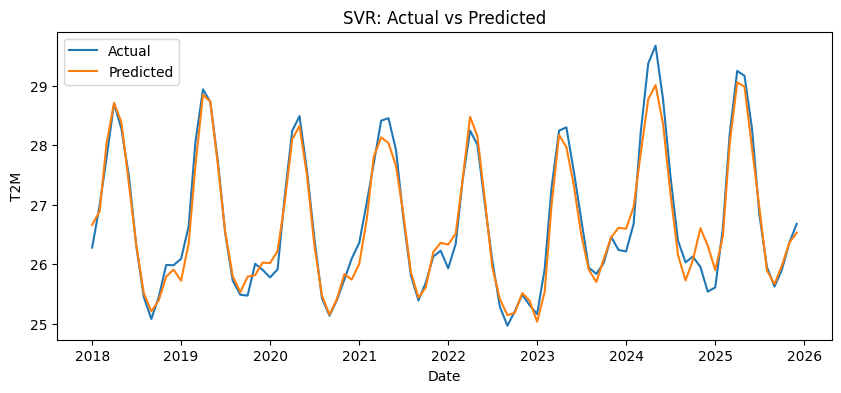

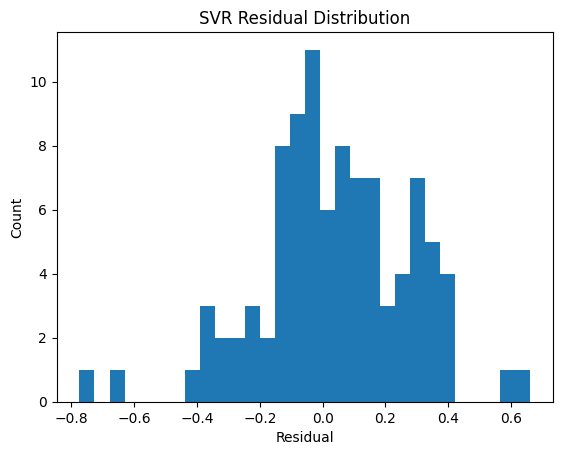

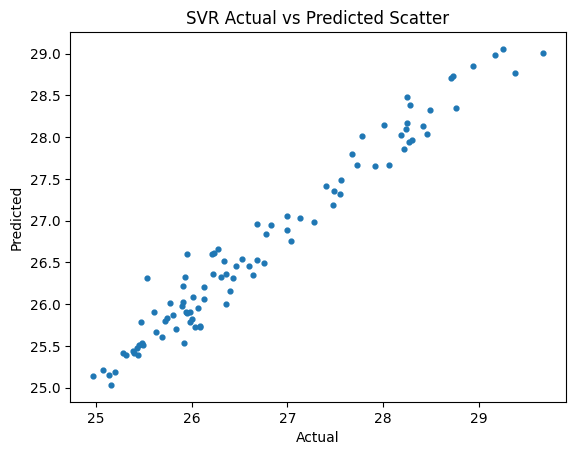

In [12]:
tscv = TimeSeriesSplit(n_splits=5)

svr = SVR(kernel="rbf")

svr_grid = {
    "C": [10, 50, 100],
    "gamma": [0.01, 0.05, 0.1],
    "epsilon": [0.01, 0.05, 0.1]
}

svr_search = GridSearchCV(
    svr,
    svr_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

svr_search.fit(X_train_aug, y_train_aug)

svr_best = svr_search.best_estimator_
print("Best SVR params:", svr_search.best_params_)

svr_pred_s = svr_best.predict(X_test_s)
svr_pred = y_scaler.inverse_transform(svr_pred_s.reshape(-1, 1)).ravel()

svr_mae, svr_rmse, svr_mape, svr_r2 = regression_metrics(y_test_inv, svr_pred)

print("SVR Metrics:", {
    "MAE": svr_mae,
    "RMSE": svr_rmse,
    "MAPE%": svr_mape,
    "R2": svr_r2
})

plot_actual_vs_pred(dates_test, y_test_inv, svr_pred, "SVR: Actual vs Predicted")
plot_residuals(y_test_inv, svr_pred, "SVR")

## RANDOM FOREST - RF

Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}
Random Forest Metrics: {'MAE': 0.26813091758241775, 'RMSE': np.float64(0.32995753658183213), 'MAPE%': np.float64(1.0079994997766317), 'R2': 0.9227722251776636}


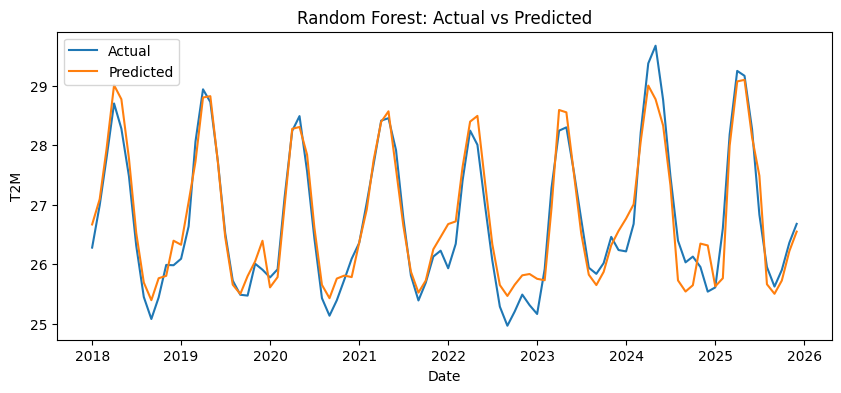

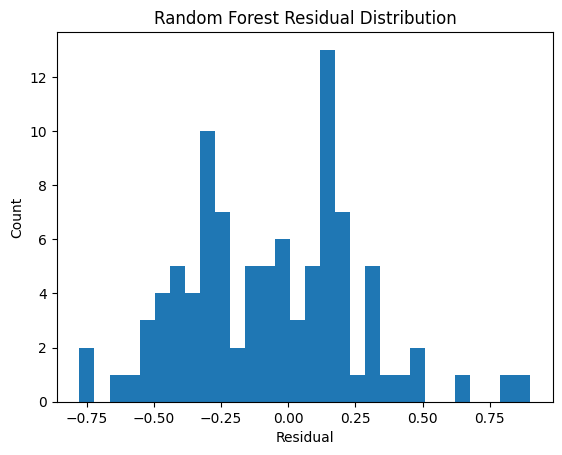

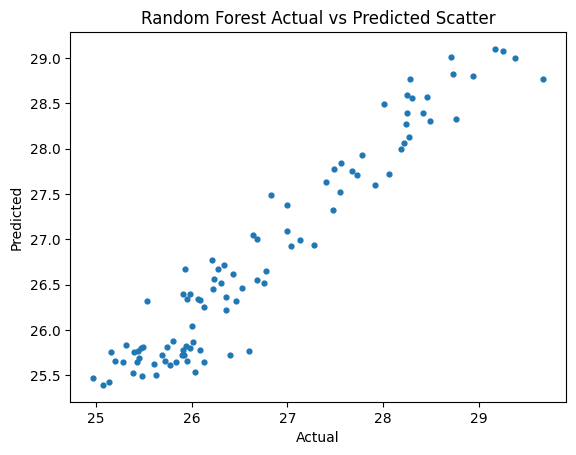

In [13]:
rf = RandomForestRegressor(random_state=RANDOM_SEED)

rf_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rf_search = GridSearchCV(
    rf,
    rf_grid,
    cv=tscv,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rf_search.fit(X_train_aug, y_train_aug)

rf_best = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)

rf_pred_s = rf_best.predict(X_test_s)
rf_pred = y_scaler.inverse_transform(rf_pred_s.reshape(-1, 1)).ravel()

rf_mae, rf_rmse, rf_mape, rf_r2 = regression_metrics(y_test_inv, rf_pred)

print("Random Forest Metrics:", {
    "MAE": rf_mae,
    "RMSE": rf_rmse,
    "MAPE%": rf_mape,
    "R2": rf_r2
})

plot_actual_vs_pred(dates_test, y_test_inv, rf_pred, "Random Forest: Actual vs Predicted")
plot_residuals(y_test_inv, rf_pred, "Random Forest")

## RF FEATURE IMPORTANCE

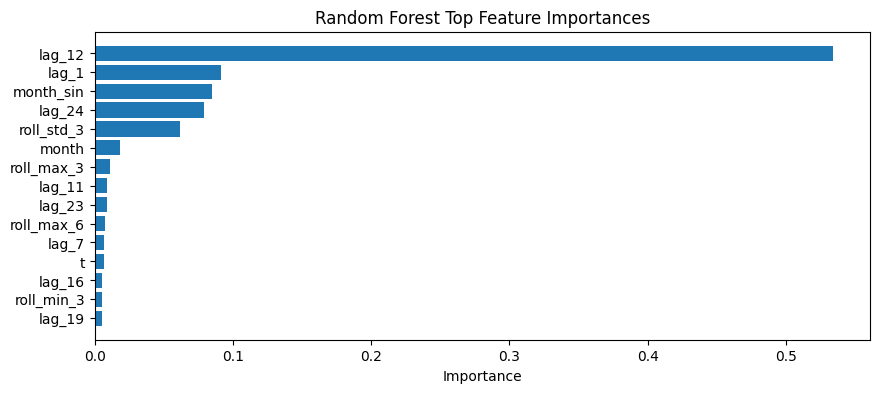

In [14]:
importances = rf_best.feature_importances_
feat_names = train_df.drop(columns=["DATE", "Y"]).columns

idx = np.argsort(importances)[-15:]

plt.figure(figsize=(10, 4))
plt.barh(feat_names[idx], importances[idx])
plt.title("Random Forest Top Feature Importances")
plt.xlabel("Importance")
plt.show()

## LONG SHORT TERM MEMORY - LSTM

In [ ]:
LOOKBACK = 12

series_dates = feat["DATE"].values
series_y = y_scaler.transform(feat["Y"].values.reshape(-1, 1)).ravel()

split_index = len(train_df)

train_y = series_y[:split_index]
test_y = series_y[split_index:]

train_dates_seq = series_dates[:split_index]
test_dates_seq = series_dates[split_index:]


def make_sequences(arr, lookback=12):
    X, y = [], []

    for i in range(len(arr) - lookback):
        X.append(arr[i:i + lookback])
        y.append(arr[i + lookback])

    return np.array(X), np.array(y)


Xtr_seq, ytr_seq = make_sequences(train_y, LOOKBACK)
Xte_seq, yte_seq = make_sequences(test_y, LOOKBACK)


def jitter_sequences(X, std=0.01, copies=2):
    Xs = [X]

    for _ in range(copies):
        Xs.append(X + np.random.normal(0, std, size=X.shape))

    return np.vstack(Xs)


Xtr_seq_aug = jitter_sequences(Xtr_seq, std=AUGMENT_NOISE_STD, copies=2)
ytr_seq_aug = np.hstack([ytr_seq, ytr_seq, ytr_seq])

Xtr_seq_aug = Xtr_seq_aug.reshape((-1, LOOKBACK, 1))
Xte_seq = Xte_seq.reshape((-1, LOOKBACK, 1))

lstm = Sequential([
    LSTM(64, input_shape=(LOOKBACK, 1), return_sequences=False),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1)
])

lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", patience=5, factor=0.5, min_lr=1e-5)
]

history = lstm.fit(
    Xtr_seq_aug,
    ytr_seq_aug,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    verbose=0,
    callbacks=callbacks
)

lstm_pred_s = lstm.predict(Xte_seq).ravel()

lstm_pred = y_scaler.inverse_transform(lstm_pred_s.reshape(-1, 1)).ravel()
yte_inv = y_scaler.inverse_transform(yte_seq.reshape(-1, 1)).ravel()

lstm_test_dates = test_dates_seq[LOOKBACK:]

lstm_mae, lstm_rmse, lstm_mape, lstm_r2 = regression_metrics(yte_inv, lstm_pred)

print("LSTM Metrics:", {
    "MAE": lstm_mae,
    "RMSE": lstm_rmse,
    "MAPE%": lstm_mape,
    "R2": lstm_r2
})

plot_actual_vs_pred(lstm_test_dates, yte_inv, lstm_pred, "LSTM: Actual vs Predicted")
plot_residuals(yte_inv, lstm_pred, "LSTM")

I0000 00:00:1787859655.459811      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1787859658.864235     140 cuda_dnn.cc:529] Loaded cuDNN version 91002


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
LSTM Metrics: {'MAE': 0.16352722305625222, 'RMSE': np.float64(0.21053407833809132), 'MAPE%': np.float64(0.6152486766589093), 'R2': 0.9689158371616382}


## LSTM TRAINING CURVE PLOT 

In [ ]:
plt.figure()
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()

## NAIVE BAYES CLASSIFICATION BASELINE

In [ ]:
train_y_cont = train_df["Y"].values

q1, q2 = np.quantile(train_y_cont, [1/3, 2/3])

def to_class(y):
    return np.digitize(y, bins=[q1, q2])

y_train_cls = to_class(train_df["Y"].values)
y_test_cls = to_class(test_df["Y"].values)

nb = GaussianNB()
nb.fit(X_train_s, y_train_cls)

nb_pred = nb.predict(X_test_s)

acc = accuracy_score(y_test_cls, nb_pred)
f1 = f1_score(y_test_cls, nb_pred, average="macro")

print("Naive Bayes Classification Metrics:", {
    "Accuracy": acc,
    "F1_macro": f1
})

print(classification_report(y_test_cls, nb_pred))

cm = confusion_matrix(y_test_cls, nb_pred)

plt.figure()
plt.imshow(cm, aspect="auto")
plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()
plt.show()

## FINAL MODEL COMPARISON

In [ ]:
results = pd.DataFrame({
    "Model": ["SVR", "Random Forest", "LSTM"],
    "MAE": [svr_mae, rf_mae, lstm_mae],
    "RMSE": [svr_rmse, rf_rmse, lstm_rmse],
    "MAPE": [svr_mape, rf_mape, lstm_mape],
    "R2": [svr_r2, rf_r2, lstm_r2]
})

results

## COMPARISON PLOT

In [ ]:
for metric in ["MAE", "RMSE", "MAPE"]:
    plt.figure(figsize=(7, 4))
    plt.bar(results["Model"], results[metric])
    plt.title(f"Model Comparison by {metric}")
    plt.xlabel("Model")
    plt.ylabel(metric)
    plt.show()

plt.figure(figsize=(7, 4))
plt.bar(results["Model"], results["R2"])
plt.title("Model Comparison by R² Score")
plt.xlabel("Model")
plt.ylabel("R²")
plt.show()

## BEST MODEL CONCLUSION

In [ ]:
best_mae_model = results.loc[results["MAE"].idxmin(), "Model"]
best_rmse_model = results.loc[results["RMSE"].idxmin(), "Model"]
best_mape_model = results.loc[results["MAPE"].idxmin(), "Model"]
best_r2_model = results.loc[results["R2"].idxmax(), "Model"]

print("Best Model by MAE:", best_mae_model)
print("Best Model by RMSE:", best_rmse_model)
print("Best Model by MAPE:", best_mape_model)
print("Best Model by R²:", best_r2_model)

overall_best = results.sort_values(
    by=["RMSE", "MAE", "MAPE"],
    ascending=[True, True, True]
).iloc[0]["Model"]

print(f"""
Conclusion:
Based on the comparative evaluation, {overall_best} performed best overall for Ghana monthly temperature forecasting.

The conclusion is mainly based on lower RMSE, MAE, and MAPE values, since these indicate smaller forecasting errors. The R² score was also considered because a higher R² means the model explains more variation in the temperature data.

Therefore, {overall_best} can be considered the most suitable model among SVR, Random Forest, and LSTM for forecasting monthly temperature using the 1984–2025 Ghana climate time-series dataset.
""")